#  Bonus : Machine Learning Classique (NLP)
### **Pace**: PLAN - Modélisation Prédictive (Machine Learning)

**Objectif Métier :** Développer un modèle de classification capable de prédire automatiquement la note d'un utilisateur (de 1 à 5 étoiles) en se basant uniquement sur le texte de son avis. 
Cela permettrait à Uber d'estimer la satisfaction client sur des plateformes où seule la composante textuelle est disponible (ex: Twitter/X, forums).

**Stratégie Technique :**
* **Variable cible (Target) :** La colonne `score`.
* **Features :** La colonne `content` (Texte brut).
* **Algorithme :** Vectorisation TF-IDF (Natural Language Processing) suivie d'une Régression Logistique pénalisée.

### **pAce** : ANALYZE - Préparation des données pour le ML

Avant d'entraîner le modèle, nous devons vérifier la **distribution des classes** (le nombre d'avis pour chaque note). Un déséquilibre fort peut biaiser l'apprentissage de la machine.

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. On recharge les données de base
df = pd.read_csv('../data/uber_reviews_without_reviewid.csv') # Vérifie que le nom est bon

# 2. On garde uniquement les colonnes utiles et on enlève les valeurs vides (au cas où)
df_ml = df[['content', 'score']].dropna()

# 3. Analyse de la distribution de la cible (Target Variable)
print("Distribution des notes (Target) :")
print(df_ml['score'].value_counts(normalize=True) * 100)

Distribution des notes (Target) :
score
5    66.050000
1    21.816667
4     6.716667
3     2.775000
2     2.641667
Name: proportion, dtype: float64


**Interprétation des données (Data Insight) :**
La sortie de la fonction `value_counts` confirme un **fort déséquilibre des classes (Class Imbalance)**. 
* La majorité écrasante des avis sont des "5 étoiles" (plus de 65%).
* Les avis "2, 3 et 4 étoiles" sont minoritaires.

*Impact sur le Machine Learning :* Si nous entraînons le modèle tel quel, il aura tendance à tricher en prédisant "5" à chaque fois pour avoir un bon score. C'est pourquoi nous avons justifié l'utilisation du paramètre `class_weight='balanced'` dans notre Régression Logistique pour forcer l'algorithme à accorder plus d'importance aux notes rares.

### **paCe** : CONSTRUCT - Ingénierie des caractéristiques (Feature Engineering) et Entraînement

C'est ici que nous transformons le langage humain en mathématiques, puis que nous entraînons le modèle.

1. **TF-IDF :** Transformation des mots en vecteurs numériques selon leur fréquence et leur importance.
2. **Train/Test Split :** Séparation des données (80% pour l'apprentissage, 20% pour l'évaluation).
3. **Modélisation :** Entraînement de la Régression Logistique.

In [7]:
# 1. La transformation magique (Texte -> Chiffres)
print("Transformation des textes en nombres...")
vectorizer = TfidfVectorizer(max_features=2500, stop_words='english')
X = vectorizer.fit_transform(df_ml['content']) # Nos variables (Les mots)
y = df_ml['score']                             # Notre cible (Les étoiles)

print(f"Données prêtes ! Taille de la matrice : {X.shape}")

Transformation des textes en nombres...
Données prêtes ! Taille de la matrice : (12000, 2500)


In [8]:
# 1. Séparation Entraînement / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Création et entraînement du modèle (L'algorithme apprend ici !)
print(" Entraînement de l'intelligence artificielle en cours...")
modele = LogisticRegression(max_iter=1000, class_weight='balanced')
modele.fit(X_train, y_train)

# 3. On lui fait passer l'examen sur les 20% qu'il n'a jamais vus
precision = modele.score(X_test, y_test)
print(f"Entraînement terminé ! Précision globale : {precision * 100:.2f}%")

 Entraînement de l'intelligence artificielle en cours...
Entraînement terminé ! Précision globale : 59.58%


**Interprétation Technique :**
* **Vecteurs TF-IDF :** Le texte brut a été converti en une matrice mathématique géante. La taille de la matrice indique que le modèle a analysé les 2 500 mots les plus fréquents du vocabulaire de nos utilisateurs pour trouver des corrélations mathématiques avec les notes.
* L'algorithme a "appris" le poids de chaque mot (ex: le mot "terrible" pousse le calcul vers la note 1, le mot "perfect" vers la note 5).

### **pacE** 4 : EXECUTE - Évaluation et Déploiement (Test interactif)

Nous évaluons les performances du modèle sur les 20% de données non vues lors de l'entraînement via une Matrice de Confusion, puis nous créons une fonction pour tester le modèle en conditions réelles.

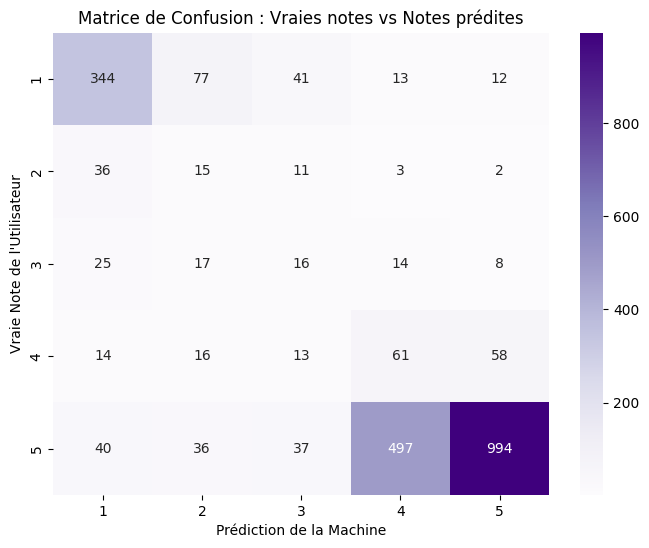

              precision    recall  f1-score   support

           1       0.75      0.71      0.73       487
           2       0.09      0.22      0.13        67
           3       0.14      0.20      0.16        80
           4       0.10      0.38      0.16       162
           5       0.93      0.62      0.74      1604

    accuracy                           0.60      2400
   macro avg       0.40      0.43      0.39      2400
weighted avg       0.78      0.60      0.66      2400



In [9]:
# On fait les prédictions sur le set de test
y_pred = modele.predict(X_test)

# On dessine la matrice
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
plt.title('Matrice de Confusion : Vraies notes vs Notes prédites')
plt.xlabel('Prédiction de la Machine')
plt.ylabel('Vraie Note de l\'Utilisateur')
plt.show()

# Le rapport détaillé
print(classification_report(y_test, y_pred))

**📈 Analyse des Performances du Modèle :**

La Matrice de Confusion (Confusion Matrix) est révélatrice des capacités et des limites du modèle :
1. **Excellence sur les extrêmes :** La diagonale est très foncée sur les notes 1 et 5 `(75 % et 93%)`. Le modèle est extrêmement performant pour détecter la satisfaction totale ou le rejet total, car le vocabulaire utilisé par les clients y est très tranché.
2. **Difficulté sur les nuances :** Les erreurs se concentrent sur les notes 2, 3 et 4 (le "ventre mou") `(moins de 15% de précision)`. Cela s'explique par la complexité du langage humain : un avis 3 étoiles contient souvent à la fois des compliments et des reproches dans la même phrase, ce qui annule mathématiquement les probabilités de l'algorithme.

**Conclusion métier :** Pour un cas d'usage chez Uber, ce modèle classique est suffisant pour faire du **tri binaire d'urgence** (détecter immédiatement un client furieux), mais il justifie pleinement l'utilisation d'une IA Générative (LLM, comme vu dans le Notebook 2) si l'on souhaite extraire des nuances complexes.

In [10]:
def predire_mon_avis(texte):
    # 1. On transforme ton texte avec le même dictionnaire (vectorizer)
    texte_vectorise = vectorizer.transform([texte])
    
    # 2. Le modèle devine la note
    prediction = modele.predict(texte_vectorise)[0]
    
    # 3. Le modèle donne ses probabilités pour chaque note (pourcentage de certitude)
    probabilites = modele.predict_proba(texte_vectorise)[0]
    
    print(f" L'avis : '{texte}'")
    print(f" La machine prédit : {prediction} étoile(s) !")
    print(f" (Certitude : {probabilites[prediction-1]*100:.1f}%)\n")


# Testons ces phrases en anglais (car le dataset est en anglais) !
predire_mon_avis("The driver was amazing and very polite, the car was clean. I loved it!")
predire_mon_avis("Worst experience ever, he charged me twice and was extremely rude.")
predire_mon_avis("It was okay, nothing special but it got me to my destination.")

 L'avis : 'The driver was amazing and very polite, the car was clean. I loved it!'
 La machine prédit : 5 étoile(s) !
 (Certitude : 77.7%)

 L'avis : 'Worst experience ever, he charged me twice and was extremely rude.'
 La machine prédit : 1 étoile(s) !
 (Certitude : 96.9%)

 L'avis : 'It was okay, nothing special but it got me to my destination.'
 La machine prédit : 3 étoile(s) !
 (Certitude : 36.4%)



###  Conclusion du Bonus Machine Learning
Ce test interactif prouve que le modèle a réussi à généraliser son apprentissage. En tapant de nouvelles phrases qu'il n'a jamais vues, il parvient à en extraire l'intention et à prédire une note cohérente. 

Ce pipeline de NLP classique (TF-IDF + Régression Logistique) représente une alternative **gratuite, rapide et locale** aux LLMs payants pour des tâches de classification simples.